## Moment expansion formalism for low-frequency foreground fitting and Global 21cm extraction

Zheng Zhang, 11 Jul 2025

This notebook provides a comprehensive analysis of the project, with each part being lightweight.

In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../MERS/')

from fg_model import *
from beam_model import Chromatic_Sinc_Squared, Achromatic_Gaussian_Beam, plot_svd_beam_modes
from SEDfitting import *
from measurement import *

Fundamental setup

In [2]:
colors = ['DarkOrange', 'RoyalBlue', 'ForestGreen', 'Crimson', 'Purple', 'Gray']
linestyles = ['-', '--', '-.', ':']

In [3]:
# Set up the frequency list: [50, 200] MHz
freq_list = np.linspace(50., 200., 101)
Nfreq = len(freq_list)

# Set up the Nside for full map analysis
Nside = 128

# Set up a chromatica beam
def fwhm_function(nu_mhz, params):
    return params["K"] / nu_mhz

fwhm_func_params = {"K": 4000}

Sinc_ch_beam = Chromatic_Sinc_Squared(freq_list, fwhm_function, fwhm_func_params, nside=Nside)
Sinc_ch_beam.get_beam_l()
Sinc_ch_bl0 = Sinc_ch_beam.bl_list
Sinc_ch_bl = [ B_l0 * np.sqrt(4 * np.pi / (2 * np.arange(len(B_l0)) + 1)) for B_l0 in Sinc_ch_bl0 ]

Gaussian_beam = Achromatic_Gaussian_Beam(60, Nfreq, nside=Nside)
Gaussian_beam.get_beam_l()
Gaussian_ach_bl0 = Gaussian_beam.bl_list
Gaussian_ach_bl = [ B_l0 * np.sqrt(4 * np.pi / (2 * np.arange(len(B_l0)) + 1)) for B_l0 in Gaussian_ach_bl0 ]


# Set up sky models:

# 1. CNN-PL sky model
CNN_sky, pivot_specidx_map = CNN_PL_sky(freq_list, beam_transfer=None, nside=Nside, return_spec_index=True)

# 2. GSM sky model
GSM_sky = GSM_maps(freq_list, nside=Nside, beam_transfer=None) 

# 3. Achromatic Gaussian beam
CNN_gaussian = CNN_PL_sky(freq_list, beam_transfer=Gaussian_ach_bl, nside=Nside, return_spec_index=False)

# 4. Chromatic Beam-convolved CNN-PL sky model
CNN_Sinc = CNN_PL_sky(freq_list, beam_transfer=Sinc_ch_bl, nside=Nside, return_spec_index=False)

# # 5. CNN-PL plus point source sky model
# ptsrc_Sinc = ptsrc(freq_list, nside=Nside, beam_transfer=Sinc_ch_bl).maps
# full_fg = ptsrc(freq_list, nside=Nside).maps + CNN_sky 
# full_fg_gaussian = ptsrc(freq_list, nside=Nside, beam_transfer=Gaussian_ach_bl).maps + CNN_gaussian
# full_fg_Sinc = ptsrc_Sinc + CNN_Sinc

# 6. Set up an instance of global 21cm signal, and generate the full radio sky with fg and gs
gs = np.load('global_signal_50_200.npy')
gs *= 1e-3 # mK --> K
# full_sky = full_fg + gs[np.newaxis, :] + 2.725 # Add CMB temperature (2.7 K)
# full_sky_gaussian = full_fg_gaussian + gs[np.newaxis, :] + 2.725
# full_sky_Sinc = full_fg_Sinc + gs[np.newaxis, :] + 2.725
full_fg = CNN_sky
full_fg_gaussian = CNN_gaussian
full_fg_Sinc = CNN_Sinc
full_sky = CNN_sky + gs[np.newaxis, :] + 2.725 # Add CMB temperature (2.7 K)
full_sky_gaussian = CNN_gaussian + gs[np.newaxis, :] + 2.725
full_sky_Sinc = CNN_Sinc + gs[np.newaxis, :] + 2.725


In [4]:
# ptsrc_maps = ptsrc(freq_list, nside=Nside).maps
# hp.mollview(ptsrc_maps[:, 50], title='Point Sources at 50 MHz', cmap='jet', norm='log')
# plt.show()

In [5]:

# 7. Maps (full_fg, shape: (Npix, Nfreq) ) to alm coefficients (shape: (Nalm, Nfreq))
def maps_to_alm_comprehension(maps, lmax):
    """Convert using list comprehension."""
    return np.array([hp.map2alm(maps[:, i], lmax=lmax) for i in range(maps.shape[1])]).T

def alm_to_maps_comprehension(alms, nside):
    """
    Convert alm coefficients to HEALPix maps using list comprehension.
    """
    return np.array([hp.alm2map(alms[:, i], nside) for i in range(alms.shape[1])]).T

def low_multipole_sky(sky_maps, lmax=10):
    """
    Extract low multipole components of the sky maps.
    """
    alm = maps_to_alm_comprehension(sky_maps, lmax=lmax)
    low_ell_maps = alm_to_maps_comprehension(alm, nside=Nside)
    return low_ell_maps

lmax = 10  # Set the maximum multipole for low ell extraction

full_fg_alm = maps_to_alm_comprehension(CNN_sky, lmax=lmax)
full_sky_alm = maps_to_alm_comprehension(full_sky, lmax=lmax)
full_fg_low_ell = low_multipole_sky(CNN_sky, lmax=lmax)
full_sky_low_ell = low_multipole_sky(full_sky, lmax=lmax)

full_fg_monopole = full_fg_alm[0, :]
full_sky_monopole = full_sky_alm[0, :]

Generate time stamps of the pointings ... (as a sequence of pixel indices)

In [6]:

from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import astropy.units as u

# === JBO site ===
lat = 53.23625  # degrees
lon = -2.30744  # degrees
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)

# === Generate obs_time list（UTC）===
# From 2024-10-01 22:00 to 2024-10-02 05:00，every "delta_minutes" minute
start_time = Time('2024-10-01 21:00:00', scale='utc', location=location)
end_time   = Time('2024-10-02 05:00:00', scale='utc', location=location)
delta_minutes = 1

# Construct the time sequence
times = start_time + np.arange(0, (end_time - start_time).to_value('min') + delta_minutes, delta_minutes) * u.min

# === Calculate the corresponding LSTs ===
lst_array = times.sidereal_time('mean', longitude=lon*u.deg)

# === Constants ===
lat = 53.23625  # JBO latitude in degrees

# === Step 1: LSTs → (RA, Dec) for zenith ===
# Dec of zenith = latitude
dec_zenith = lat * u.deg
ra_zeniths = lst_array.to(u.deg)  # LST is the RA of the zenith

# Convert to spherical coordinates
# θ = colatitude = π/2 - Dec
# φ = RA (converted to radians)

phi = ra_zeniths.to(u.rad).value  # array of longitudes
theta = (90 * u.deg - dec_zenith).to(u.rad).value  # constant
theta = theta * np.ones_like(phi)  # array of colatitudes
Npointings = len(phi)
# theta = np.arccos(np.random.uniform(0, 1, Npointings))  # random North Semisphere colatitudes
# dec_pointings = (np.pi / 2 - theta)*u.rad  # convert to declination


# === Step 2: Convert to Galactic coordinates ===
skycoords_eq = SkyCoord(ra=ra_zeniths, dec=dec_zenith, frame='icrs')
skycoords_gal = skycoords_eq.galactic

# === Step 3: Convert to HEALPix pixel indices ===
# Use vector representation to feed into healpy
vecs = skycoords_gal.represent_as('cartesian').get_xyz().value  # shape: (3, N)
pix_indices = hp.vec2pix(Nside, vecs[0], vecs[1], vecs[2])

In [7]:
# TOD_Sinc = full_sky_Sinc[pix_indices, :]


# # Generate design matrix
# alm_est_list = []
# for i in range(Nfreq):
#     A, lm_list = build_design_matrix(theta, phi, Sinc_ch_bl0[i], lmax)
#     # Solve for low multipole skys:
#     Tlm_est = solve_modes(A, TOD_Sinc[:, i])
#     alm_est = convert_real_to_complex_alm(Tlm_est, lmax)
#     alm_est_list.append(alm_est)

# full_sky_alm_est = np.array(alm_est_list).T  # shape: (Nalm, Nfreq)

In [8]:
# plt.plot(full_sky_alm[0,:]/full_sky_alm[0, 0], label='True alm coefficients')
# plt.plot(full_sky_alm_est[0,:]/full_sky_alm[0, 0], label='Estimated alm coefficients')
# plt.xlabel('alm index')
# plt.ylabel('alm coefficient value')
# plt.title('Comparison of True and Estimated alm Coefficients at 50 MHz')
# plt.legend()
# plt.show()


In [9]:
# def generate_TOD_cube(theta, phi, sky_maps, b_l0_list=None):
#     Npointings = len(theta)
#     Nfreq = sky_maps.shape[1]
#     data_arr = np.zeros((Npointings, Nfreq))
#     if b_l0_list is None:
#         b_l0_list = [None] * Nfreq  # Default to no chromatic beam if not provided
#     for i in range(Nfreq):
#         alm_complex = hp.map2alm(sky_maps[:,i])
#         lmax = hp.Alm.getlmax(len(alm_complex))
#         data_arr[:, i] = evaluate_sky(theta, phi, alm_complex, lmax, B_l0=b_l0_list[i], complex_basis=True)
#     return data_arr

# TODs_full = generate_TOD_cube(theta, phi, full_radio_sky, b_l0_list=Sinc_ch_bl0)
# TODs_ftfg_conv = generate_TOD_cube(theta, phi, ptfg, b_l0_list=Sinc_ch_bl0)
# spec_ind_tod = pivot_specidx_map[pix_indices]

### 1. Diffuse Sky Model

In [10]:
def optimised_fit(data_cube, pivots, freq_list, max_order):
    *_, fitted_pivot= \
    fit_fg_cube(data_cube, pivots, freq_list, nu_ref=None, max_order=max_order, adaptive_pivot=True, remove_1st_moment=False)

    mom_coef, loss,  frac_resi = \
    fit_fg_cube(data_cube, pivots, freq_list, nu_ref=None, max_order=max_order, adaptive_pivot=False, remove_1st_moment=False)
    return mom_coef, loss, frac_resi, fitted_pivot

In [11]:
Norder = 6

############################################

# CNN-PL
CNN_coef, CNN_loss,  CNN_frac_resi, CNN_pivot= \
    optimised_fit(CNN_sky[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, Norder)

# GSM
GSM_coef, GSM_loss,  GSM_frac_resi, GSM_pivot= \
    optimised_fit(GSM_sky[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, Norder)


Text(0.5, 1.0, 'Fitting Loss (max_order=6)')

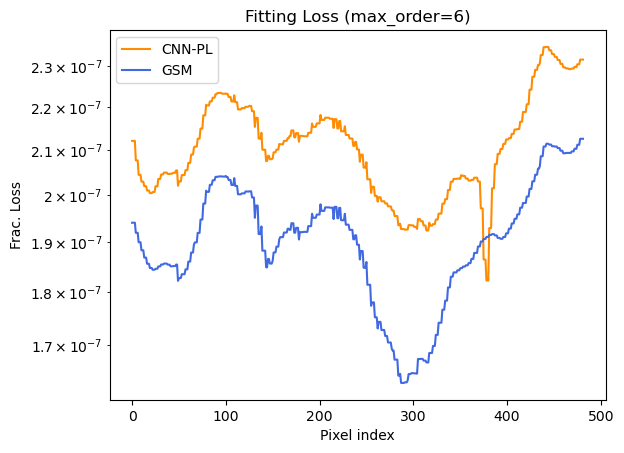

In [12]:
plt.plot(CNN_loss, label='CNN-PL', color=colors[0], linestyle=linestyles[0])
plt.plot(GSM_loss, label='GSM', color=colors[1], linestyle=linestyles[0])
 
plt.xlabel('Pixel index')
plt.ylabel('Frac. Loss')
plt.yscale('log')
plt.legend()
plt.title('Fitting Loss (max_order={})'.format(Norder))

### 2. Radio foregrounds of 21cm signal

In [13]:
Norder = 6
###################### Single pivot ######################

# Full FG (vs CNN-PL: impact of point sources)
full_fg_coef, full_fg_loss,  full_fg_frac_resi, full_fg_pivot= \
    optimised_fit(full_fg[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, Norder)

# Full FG Gaussian (vs CNN-PL: impact of achromatic Gaussian beam)
full_fg_gaussian_coef, full_fg_gaussian_loss,  full_fg_gaussian_frac_resi, full_fg_gaussian_pivot= \
    optimised_fit(full_fg_gaussian[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, Norder)

# Full FG Sinc (vs CNN-PL: impact of chromatic Sinc beam)
full_fg_Sinc_coef, full_fg_Sinc_loss,  full_fg_Sinc_frac_resi, full_fg_Sinc_pivot= \
    optimised_fit(full_fg_Sinc[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, Norder)


In [14]:
def optimised_fit_2pivots(data_cube, pivot1, pivot2, freq_list, max_order1, max_order2):
    *_, pivot1_2adapt, pivot2_2adapt = \
        fit_fg_cube_2pivots(data_cube, pivot1, pivot2, freq_list, nu_ref=None, max_order1=max_order1, max_order2=max_order2, adaptive_pivot=True)

    mom_coef, loss, frac_resi= \
        fit_fg_cube_2pivots(data_cube, pivot1, pivot2, freq_list, nu_ref=None, max_order1=max_order1, max_order2=max_order2, adaptive_pivot=False)
    
    return mom_coef, loss, frac_resi, pivot1_2adapt, pivot2_2adapt

In [15]:
###################### two pivot (tp) ######################
full_fg_coef_tp, full_fg_loss_tp,  full_fg_frac_resi_tp, full_fg_pivot1_tp, full_fg_pivot2_tp = \
    optimised_fit_2pivots(full_fg[pix_indices, :], pivot_specidx_map[pix_indices], pivot_specidx_map[pix_indices]*1.1, freq_list, Norder, Norder)
 
full_fg_gaussian_coef_tp, full_fg_gaussian_loss_tp,  full_fg_gaussian_frac_resi_tp, full_fg_gaussian_pivot1_tp, full_fg_gaussian_pivot2_tp = \
    optimised_fit_2pivots(full_fg_gaussian[pix_indices, :], pivot_specidx_map[pix_indices], pivot_specidx_map[pix_indices]*1.1, freq_list, Norder, Norder)

full_fg_Sinc_coef_tp, full_fg_Sinc_loss_tp,  full_fg_Sinc_frac_resi_tp, full_fg_Sinc_pivot1_tp, full_fg_Sinc_pivot2_tp = \
    optimised_fit_2pivots(full_fg_Sinc[pix_indices, :], pivot_specidx_map[pix_indices], pivot_specidx_map[pix_indices]*1.1, freq_list, Norder, Norder)

In [16]:
###################### Fit the multipoles ######################         
full_fg_monopole = full_fg_alm[0,:].real.reshape(1,-1)
full_fg_monopole_coef, full_fg_monopole_loss, full_fg_monopole_frac_resi, full_fg_monopole_pivot  = optimised_fit(full_fg_monopole, np.array([np.mean(pivot_specidx_map)]), freq_list, Norder)
full_fg_monopole_coef_tp, full_fg_monopole_loss_tp, full_fg_monopole_frac_resi_tp, full_fg_monopole_pivot1_tp, full_fg_monopole_pivot2_tp  =\
      optimised_fit_2pivots(full_fg_monopole, np.array([np.mean(pivot_specidx_map)]), np.array([np.mean(pivot_specidx_map*1.1)]), freq_list, Norder, Norder)

In [17]:
full_fg_monopole_loss

array([3.93033882e-07])

In [18]:
full_sky_monopole = full_sky_monopole.real.reshape(1,-1)

full_sky_monopole_coef, full_sky_monopole_loss, full_sky_monopole_frac_resi, full_sky_monopole_pivot  = optimised_fit(full_sky_monopole, np.array([np.mean(pivot_specidx_map)]), freq_list, Norder)


In [19]:
full_sky_monopole_loss

array([1.81486653e-05])

Text(0.5, 1.0, 'Fitting Loss (max_order=6)')

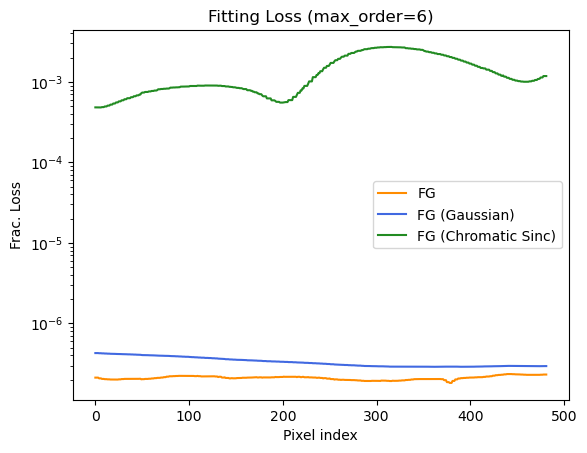

In [20]:
plt.plot(full_fg_loss, label='FG', color=colors[0], linestyle=linestyles[0])
plt.plot(full_fg_gaussian_loss, label='FG (Gaussian)', color=colors[1], linestyle=linestyles[0])
plt.plot(full_fg_Sinc_loss, label='FG (Chromatic Sinc)', color=colors[2], linestyle=linestyles[0])
# plt.plot(full_fg_loss_tp, label='FG (2 pivots)', color=colors[0], linestyle=linestyles[1])
# plt.plot(full_fg_gaussian_loss_tp, label='FG (2 pivots; Gaussian)', color=colors[1], linestyle=linestyles[1])
# plt.plot(full_fg_Sinc_loss_tp, label='FG (2 pivots; Sinc)', color=colors[2], linestyle=linestyles[1])
 
plt.xlabel('Pixel index')
plt.ylabel('Frac. Loss')
plt.yscale('log')
plt.legend()
plt.title('Fitting Loss (max_order={})'.format(Norder))

Text(0.5, 1.0, 'Fitting Loss (max_order=6)')

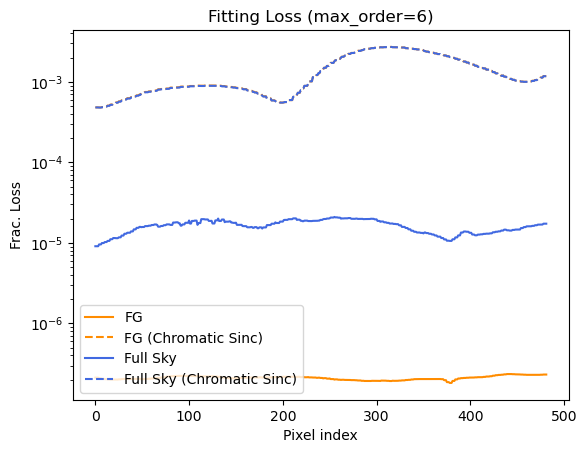

In [21]:
full_sky_coef, full_sky_loss,  full_sky_frac_resi, full_sky_pivot= \
    optimised_fit(full_sky[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, Norder)

full_sky_Sinc_coef, full_sky_Sinc_loss,  full_sky_Sinc_frac_resi, full_sky_Sinc_pivot= \
    optimised_fit(full_sky_Sinc[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, Norder)

plt.plot(full_fg_loss, label='FG', color=colors[0], linestyle=linestyles[0])
plt.plot(full_fg_Sinc_loss, label='FG (Chromatic Sinc)', color=colors[0], linestyle=linestyles[1])

plt.plot(full_sky_loss, label='Full Sky', color=colors[1], linestyle=linestyles[0])
plt.plot(full_sky_Sinc_loss, label='Full Sky (Chromatic Sinc)', color=colors[1], linestyle=linestyles[1])

# plt.plot(full_fg_loss_tp, label='FG (2 pivots)', color=colors[0], linestyle=linestyles[1])
# plt.plot(full_fg_gaussian_loss_tp, label='FG (2 pivots; Gaussian)', color=colors[1], linestyle=linestyles[1])
# plt.plot(full_fg_Sinc_loss_tp, label='FG (2 pivots; Sinc)', color=colors[2], linestyle=linestyles[1])
 
plt.xlabel('Pixel index')
plt.ylabel('Frac. Loss')
plt.yscale('log')
plt.legend()
plt.title('Fitting Loss (max_order={})'.format(Norder))


### Beam chromaticity methods

In [29]:
Sinc_U, Sinc_S, Sinc_Vh = Sinc_ch_beam.generate_SVD_beams()

# BCF
ref_beam_window = Sinc_ch_beam.bl_list[50]
ref_map = CNN_sky[:, 50]
Sinc_BCF_cube = np.array(Sinc_ch_beam.generate_BCF(ref_map, ref_beam_window))

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


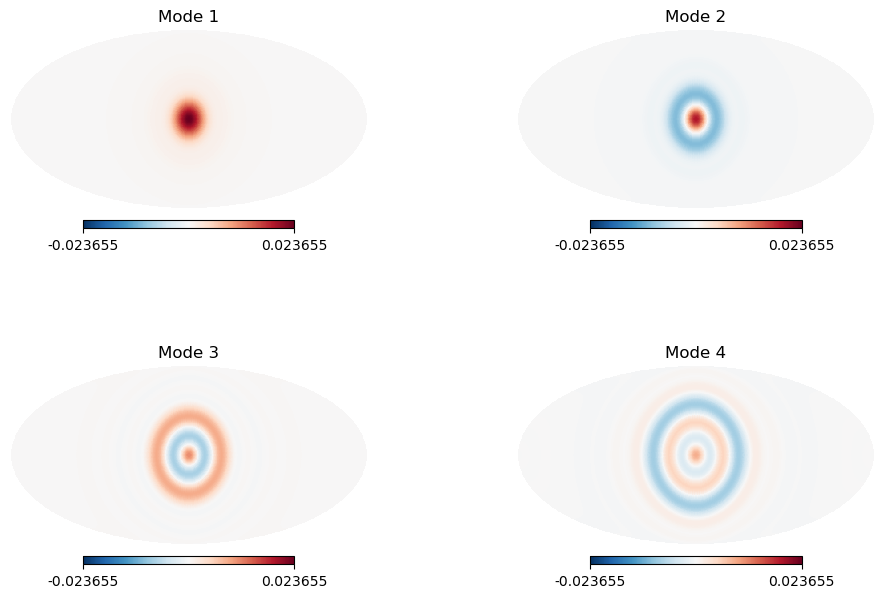

In [23]:
plot_svd_beam_modes(Sinc_Vh, nest=False)

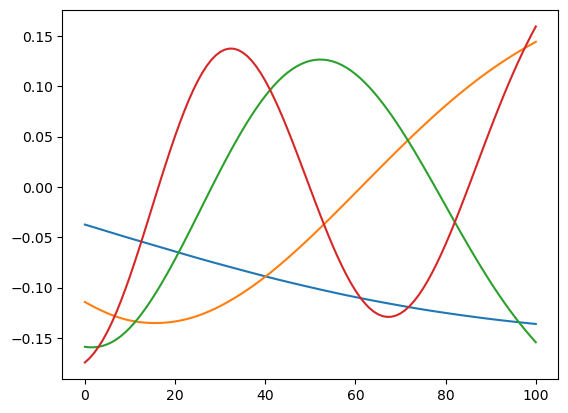

In [24]:
plt.plot(Sinc_U[:, :4])

### 3. Global 21cm extraction

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the global 21cm signal freq-freq covariance matrix
cov_gs_50_200 = np.load('signal_cov_50_200.npy')
GS_object_50_200 = Global_21cm_extraction(freq_list)

eta_50_200=[]
eta_50_200_BCF=[]
eta_50_200_SVD3=[]


for n in range(1, 12):
    eta_50_200.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, remove_1st_moment=False))
    eta_50_200_BCF.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, remove_1st_moment=False, BCF=Sinc_BCF_cube))
    eta_50_200_SVD3.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, remove_1st_moment=False, BCSVD=Sinc_U[:, :3]))
# Visualization
eta_50_200 = np.array(eta_50_200) * 100  # Convert to percentage
eta_50_200_BCF = np.array(eta_50_200_BCF) * 100
eta_50_200_SVD3 = np.array(eta_50_200_SVD3) * 100
orders_li = np.arange(1, 12)
plt.figure(figsize=(8, 6))
plt.semilogy(orders_li, eta_50_200,'s-', color='royalblue', label='No BCF/SVD')
plt.semilogy(orders_li, eta_50_200_BCF,'o-', color='darkorange', label='BCF')
plt.semilogy(orders_li, eta_50_200_SVD3,'^-', color='forestgreen', label='SVD3')

plt.xlabel('Maximum Order of Moment', fontsize=12)
plt.ylabel('Frac. Resi. 21cm Signal [%]', fontsize=12)
#plt.title('Foreground Subtraction Efficiency', fontsize=14)
plt.xticks(orders_li)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(0.0, 1.15), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [ ]:
basis_gen = fg_moment_basis(freqs=freqs, nu_ref=nu_ref)

In [36]:
n_order = 8

Sinc_BCF_coeffs, Sinc_BCF_loss, Sinc_BCF_resi, Sinc_BCF_pivot = fit_fg_cube(full_fg_Sinc[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCF=Sinc_BCF_cube)



n_beam = 3
Sinc_SVD3_coeffs, Sinc_SVD3_loss, Sinc_SVD3_resi, Sinc_SVD3_pivot = fit_fg_cube(full_fg_Sinc[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=Sinc_U[:, :n_beam])

n_beam = 4
Sinc_SVD4_coeffs, Sinc_SVD4_loss, Sinc_SVD4_resi, Sinc_SVD4_pivot = fit_fg_cube(full_fg_Sinc[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=Sinc_U[:, :n_beam])

n_beam = 5
Sinc_SVD5_coeffs, Sinc_SVD5_loss, Sinc_SVD5_resi, Sinc_SVD5_pivot = fit_fg_cube(full_fg_Sinc[pix_indices, :], pivot_specidx_map[pix_indices], freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=Sinc_U[:, :n_beam])


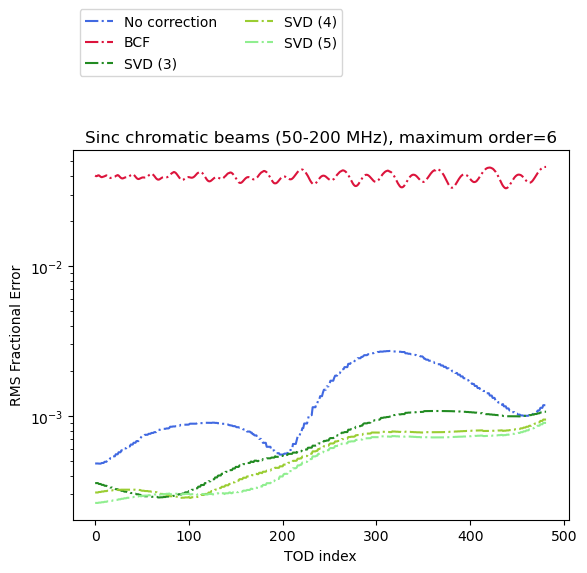

In [ ]:
green_colors = ['forestgreen', 'yellowgreen', 'lightgreen', 'palegreen', 'yellowgreen', 'limegreen', 'greenyellow', 'green', 'darkgreen']


plt.plot(full_fg_Sinc_loss, label='No correction', linestyle='-.', color='royalblue')
plt.plot(Sinc_BCF_loss, label='BCF', linestyle='-.', color='crimson')
plt.plot(Sinc_SVD3_loss, label='SVD (3 modes)', linestyle='-.', color=green_colors[0])
# plt.plot(Sinc_SVD4_loss, label='SVD (4)', linestyle='-.', color=green_colors[1])
# plt.plot(Sinc_SVD5_loss, label='SVD (5)', linestyle='-.', color=green_colors[2])

plt.yscale('log')
plt.ylabel('RMS Fractional Error')
plt.xlabel('TOD index')
plt.title('Sinc chromatic beams (50-200 MHz), maximum order={}'.format(Norder))
plt.legend(bbox_to_anchor=(0.0, 1.4), loc='upper left', ncol=2)

## Visualisations

### Visualise the residual error maps

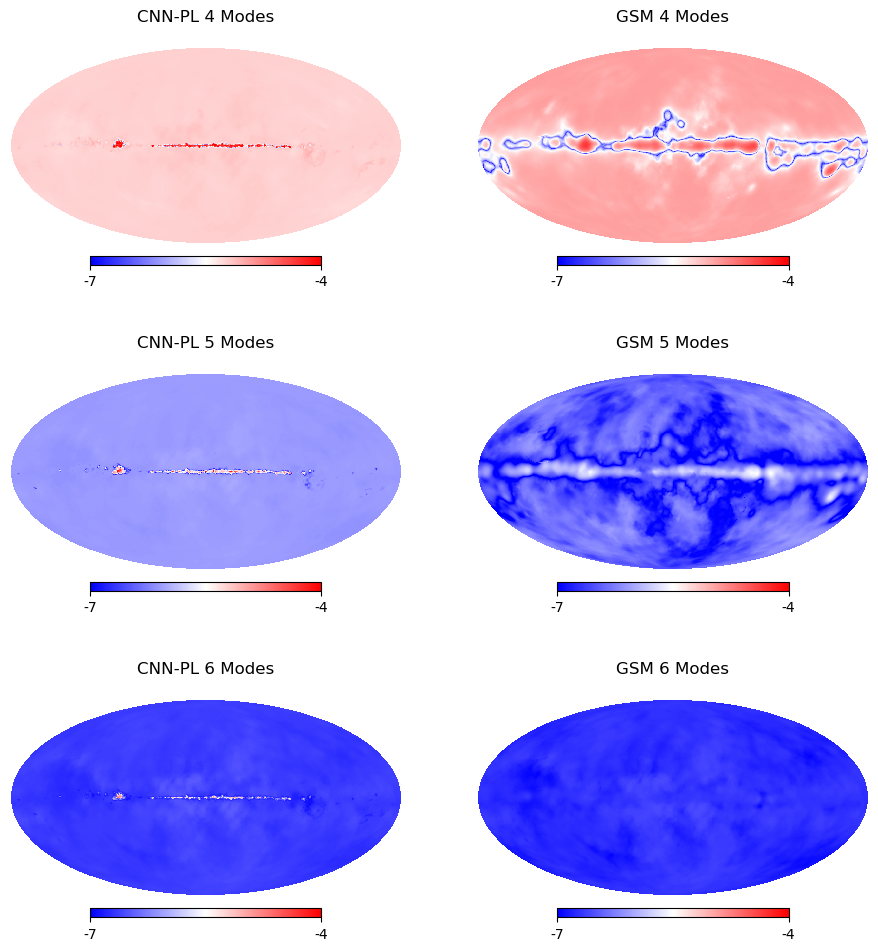

In [ ]:

# Generate a figure with 6 subplots, with the layout as 3 rows and 2 columns.
# The first row are healmaps of Mel_loss_map_3 and GSM_loss_map_3, with the same colorbar.
# The second row are healmaps of Mel_loss_map_4 and GSM_loss_map_4, with the same colorbar.
# The third row are healmaps of Mel_loss_map_5 and GSM_loss_map_5, with the same colorbar.

def plot_loss_comparison(savepath=None):
    plt.figure(figsize=(12, 12))
    
    maps = [
        (np.log10(Mel_loss_map_4_fixed), np.log10(GSM_loss_map_4), '4 Modes'), 
        (np.log10(Mel_loss_map_5_fixed), np.log10(GSM_loss_map_5), '5 Modes'),
        (np.log10(Mel_loss_map_6_fixed), np.log10(GSM_loss_map_6), '6 Modes')
    ]
    titles = ['CNN-PL', 'GSM', '']
    
    gs = plt.GridSpec(3, 2, width_ratios=[1, 1], height_ratios=[1, 1, 1], wspace=0.01)
    
    for row in range(3):
        map1, map2, label = maps[row]
        
        # vmin = min(np.nanpercentile(map1, 1), np.nanpercentile(map2, 1))
        # vmax = max(np.nanpercentile(map1, 99), np.nanpercentile(map2, 99))
        vmin = -7
        vmax = -4
        
        cbar='bwr'
        ax1 = plt.subplot(gs[row, 0], projection='mollweide')
        im1 = hp.mollview(map1, title='', hold=True, 
                          min=vmin, max=vmax, 
                          #norm='log',
                          cmap=cbar)
        plt.text(0.5, 1.1, f'{titles[0]} {label}', 
                ha='center', va='bottom', transform=ax1.transAxes, fontsize=12)
        
        ax2 = plt.subplot(gs[row, 1], projection='mollweide')
        im2 = hp.mollview(map2, title='', hold=True, 
                          min=vmin, max=vmax, 
                          #norm='log',
                          cmap=cbar)
        plt.text(0.5, 1.1, f'{titles[1]} {label}', 
                ha='center', va='bottom', transform=ax2.transAxes, fontsize=12)
        
        # cax = plt.subplot(gs[row, 2])
        # plt.colorbar(im1['cmap'], cax=cax).set_label('Loss Value', fontsize=10)
    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    #plt.suptitle('Spectral Moment Fitting Error Comparison', y=0.93, fontsize=14)
    plt.show()

plot_loss_comparison(savepath='../outputs/loss_comparison.pdf')

### Visualise the moment coefficient maps (N=6)

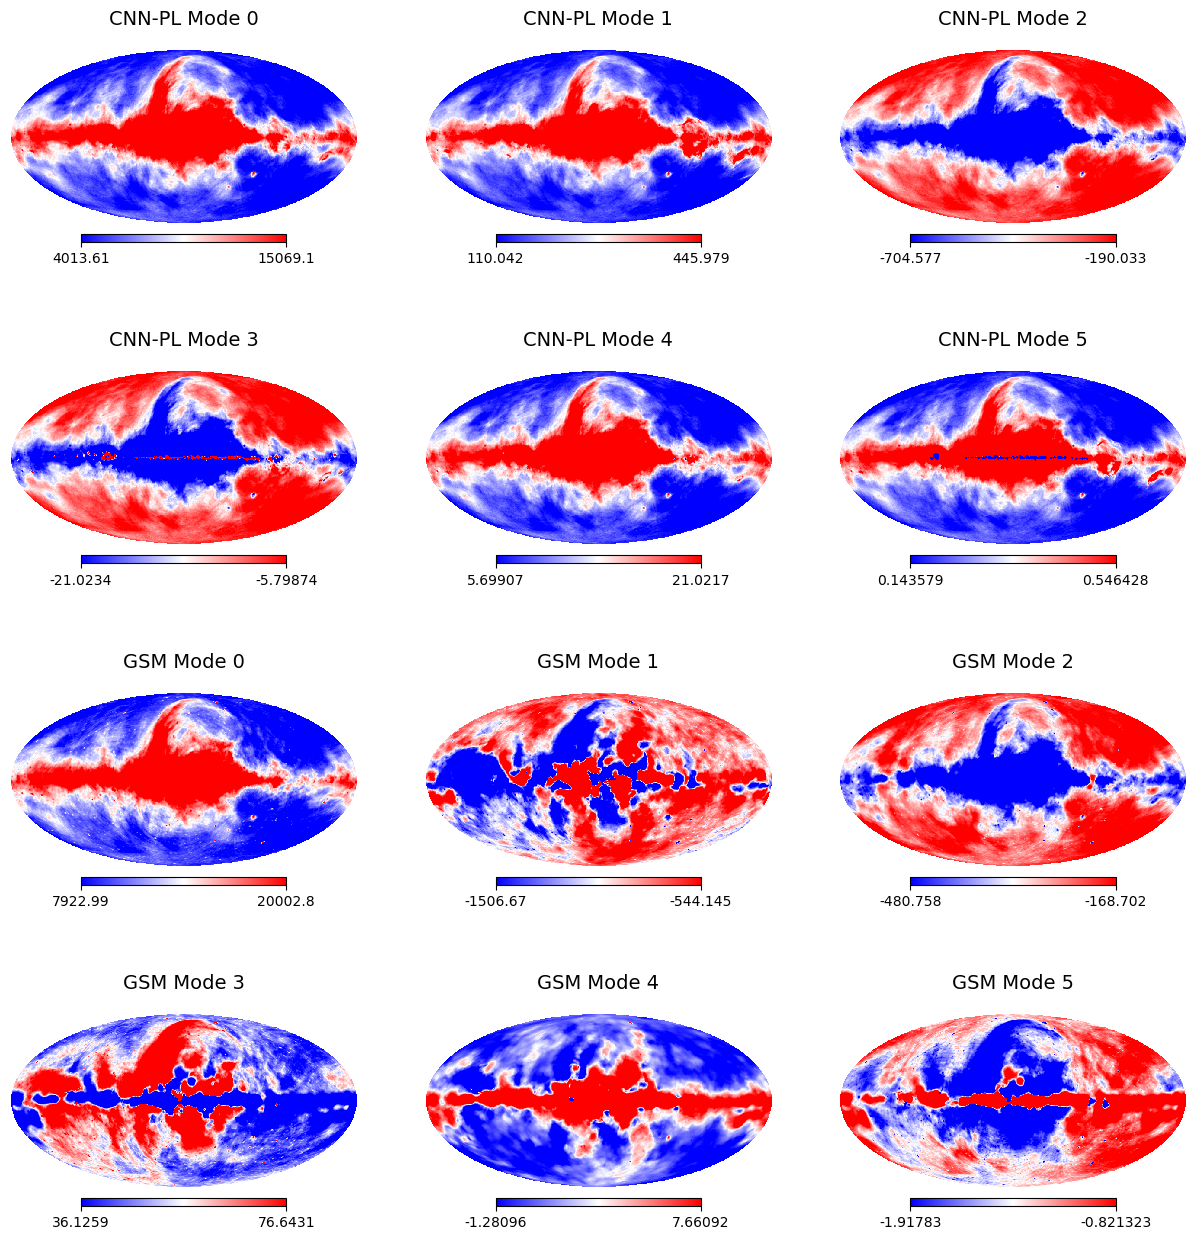

In [ ]:

def plot_moment_maps(savepath=None):
    plt.figure(figsize=(16, 16))
    

    titles = [['CNN-PL']*6, ['GSM']*6]
    
    gs = plt.GridSpec(4, 3, width_ratios=[1, 1, 1], height_ratios=[1,1,1,1], wspace=0.01)
    
    # Get the 16 and 84 percentiles
    # vmin = np.percentile(Mel_moment_coeffs_maps_6_fixed, 16)
    # vmax = np.percentile(Mel_moment_coeffs_maps_6_fixed, 84)

    vmin_ls = []
    vmax_ls = []

    for i in range(6):
        vmin_Mel = np.percentile(Mel_moment_coeffs_maps_6_fixed[:,i], 16)
        vmax_Mel = np.percentile(Mel_moment_coeffs_maps_6_fixed[:,i], 84)
        vmin_GSM = np.percentile(GSM_coeffs_maps_6[:,i], 16)
        vmax_GSM = np.percentile(GSM_coeffs_maps_6[:,i], 84)
        vmin_ls.append(min(vmin_Mel, vmin_GSM))
        vmax_ls.append(max(vmax_Mel, vmax_GSM))
        

    for row in range(2):
        for col in range(3):
            ind=row*3+col
            map=Mel_moment_coeffs_maps_6_fixed[:,ind]
            # vmin = vmin_ls[ind]
            # vmax = vmax_ls[ind]
            vmin = np.percentile(map, 16)
            vmax = np.percentile(map, 84)
        
            if ind==0:
                # not using diverging colormap
                cbar='bwr'
            else:
                # using diverging colormap
                cbar='bwr'
            ax1 = plt.subplot(gs[row, col], projection='mollweide')
            im1 = hp.mollview(map, title='', hold=True, 
                            min=vmin, max=vmax, 
                            #norm='log',
                            cmap=cbar)
            plt.text(0.5, 1.1, f'{titles[0][ind]} Mode {ind}', 
                    ha='center', va='bottom', transform=ax1.transAxes, fontsize=14)

    for row in range(2):
        for col in range(3):
            ind=row*3+col
            map=GSM_coeffs_maps_6[:,ind]

            vmin = np.percentile(map, 16)
            vmax = np.percentile(map, 84)
            # vmin = vmin_ls[ind]
            # vmax = vmax_ls[ind]
        
            if ind==0:
                # not using diverging colormap
                cbar='bwr'
            else:
                # using diverging colormap
                cbar='bwr'
            ax1 = plt.subplot(gs[row+2, col], projection='mollweide')
            im1 = hp.mollview(map, title='', hold=True, 
                            min=vmin, max=vmax, 
                            #norm='log',
                            cmap=cbar)
            plt.text(0.5, 1.1, f'{titles[1][ind]} Mode {ind}', 
                    ha='center', va='bottom', transform=ax1.transAxes, fontsize=14)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    #plt.suptitle('Spectral Moment Fitting Error Comparison', y=0.93, fontsize=14)
    plt.show()

plot_moment_maps(savepath='../outputs/moment_maps_CNNPL_GSM.pdf')